# **Day 12: Information Theory for Machine Learning**
*Module 2 - Probability, Statistics and Optimisation*

Information theory (Shannon, 1948) measures **uncertainty** and **information**. It appears everywhere in ML:
- **Entropy** and **information gain** choose splits in decision trees (Day 33).
- **Cross-entropy** is the loss of almost every classifier and neural network.
- **KL divergence** appears in VAEs (Day 71), knowledge distillation, t-SNE (Day 50) and drift detection (Day 83).
- **Mutual information** ranks features (Day 43).

> Information theory measures uncertainty and surprise. Entropy is high when outcomes are unpredictable, cross-entropy is the usual classification loss, and mutual information measures how much one variable tells us about another.
>
> *Example:* A pixel that is 50% water and 50% land (by the model's belief) has high entropy. A pixel that is 99% water has low entropy, so the model is confident.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(12)

## **1. Information and Entropy**
The **information** of an event with probability $p$ is $-\log_2 p$ bits: rare events are more surprising.
**Entropy** is the average surprise of a distribution:
$$H(X) = -\sum_x p(x)\log_2 p(x)$$
- Maximum for a uniform distribution ($\log_2 K$ for $K$ classes).
- Zero when the outcome is certain.

fair coin            H = 1.000 bits
biased coin          H = 0.469 bits
certain              H = 0.000 bits
fair die             H = 2.585 bits
4 classes, skewed    H = 1.357 bits


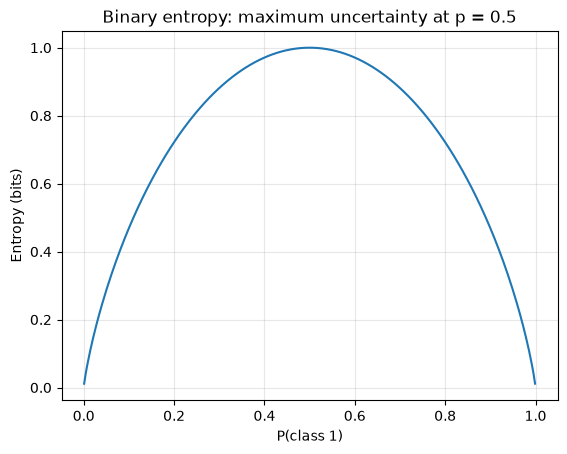

In [2]:
def entropy(p, base=2):
    p = np.asarray(p, dtype=float); p = p[p > 0]
    return abs(-np.sum(p * np.log(p)) / np.log(base))     # abs() only removes the "-0.0" sign

for name, dist in {"fair coin": [0.5, 0.5], "biased coin": [0.9, 0.1], "certain": [1, 0],
                   "fair die": [1 / 6] * 6, "4 classes, skewed": [0.7, 0.1, 0.1, 0.1]}.items():
    print(f"{name:<20} H = {entropy(dist):.3f} bits")

p = np.linspace(0.001, 0.999, 300)
plt.plot(p, [entropy([q, 1 - q]) for q in p]); plt.xlabel("P(class 1)"); plt.ylabel("Entropy (bits)")
plt.title("Binary entropy: maximum uncertainty at p = 0.5"); plt.grid(alpha=0.3); plt.show()

## **2. Conditional Entropy and Information Gain**
$H(Y\mid X) = \sum_x p(x)H(Y\mid X=x)$ is the uncertainty left about $Y$ after seeing $X$.
**Information gain** $IG(Y;X) = H(Y) - H(Y\mid X)$: how much a feature reduces uncertainty. Decision trees pick the split with the largest gain.

In [3]:
df = pd.DataFrame({
    "outlook": ["sunny"] * 5 + ["overcast"] * 4 + ["rain"] * 5,
    "windy":   [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1],
    "play":    [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0]})

def info_gain(data, feature, target="play"):
    h_y = entropy(data[target].value_counts(normalize=True))
    h_cond = sum(len(g) / len(data) * entropy(g[target].value_counts(normalize=True)) for _, g in data.groupby(feature))
    return h_y, h_cond, h_y - h_cond

for f in ["outlook", "windy"]:
    h, hc, ig = info_gain(df, f)
    print(f"{f:<8} H(Y)={h:.3f}  H(Y|X)={hc:.3f}  IG={ig:.3f}")

outlook  H(Y)=0.940  H(Y|X)=0.694  IG=0.247
windy    H(Y)=0.940  H(Y|X)=0.892  IG=0.048


`outlook` has a higher information gain, so a decision tree would split on it first.

## **3. Cross-Entropy: The Classification Loss**
If the true distribution is $p$ and the model predicts $q$:
$$H(p, q) = -\sum_x p(x)\log q(x)$$
For a one-hot label this reduces to $-\log q(\text{true class})$: the **log loss**. It punishes **confident wrong** predictions very heavily.

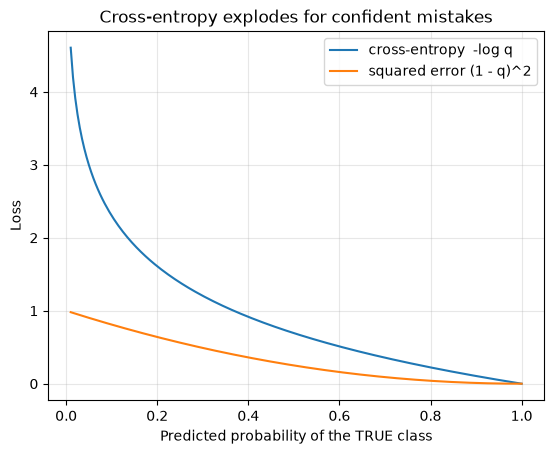

Good, calibrated predictions : 0.1976
One confident mistake        : 1.2598


In [4]:
q_true = np.linspace(0.01, 1, 200)
plt.plot(q_true, -np.log(q_true), label="cross-entropy  -log q")
plt.plot(q_true, (1 - q_true) ** 2, label="squared error (1 - q)^2")
plt.xlabel("Predicted probability of the TRUE class"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Cross-entropy explodes for confident mistakes"); plt.show()

from sklearn.metrics import log_loss
y_true = [1, 0, 1, 1]
print("Good, calibrated predictions :", round(log_loss(y_true, [0.9, 0.1, 0.8, 0.7]), 4))
print("One confident mistake        :", round(log_loss(y_true, [0.9, 0.1, 0.8, 0.01]), 4))

## **4. KL Divergence**
$$D_{KL}(p\,\|\,q) = \sum_x p(x)\log\frac{p(x)}{q(x)} = H(p,q) - H(p) \ge 0$$
It measures the **extra bits** needed when using $q$ to encode data from $p$. Since $H(p)$ is fixed by the data, **minimising cross-entropy = minimising KL divergence**.

KL is **not symmetric**: $D_{KL}(p\|q)\neq D_{KL}(q\|p)$.

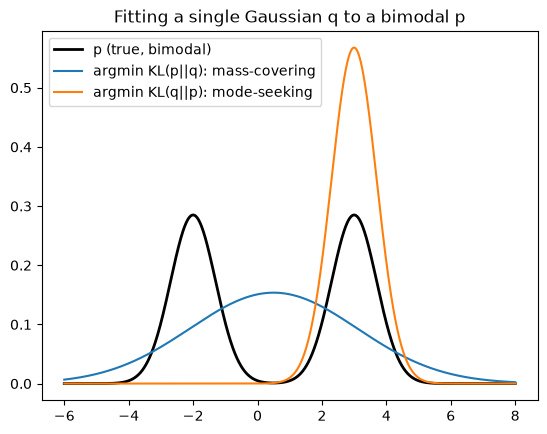

In [5]:
from scipy import stats
x = np.linspace(-6, 8, 2000); dx = x[1] - x[0]
p_bimodal = 0.5 * stats.norm.pdf(x, -2, 0.7) + 0.5 * stats.norm.pdf(x, 3, 0.7)

def kl(p, q):
    m = (p > 1e-12)
    return np.sum(p[m] * np.log(p[m] / np.maximum(q[m], 1e-300))) * dx

from scipy.optimize import minimize
fit_fwd = minimize(lambda t: kl(p_bimodal, stats.norm.pdf(x, t[0], np.exp(t[1]))), [0, 0]).x
fit_rev = minimize(lambda t: kl(stats.norm.pdf(x, t[0], np.exp(t[1])), p_bimodal), [2.5, -0.5]).x
plt.plot(x, p_bimodal, "k", lw=2, label="p (true, bimodal)")
plt.plot(x, stats.norm.pdf(x, fit_fwd[0], np.exp(fit_fwd[1])), label="argmin KL(p||q): mass-covering")
plt.plot(x, stats.norm.pdf(x, fit_rev[0], np.exp(fit_rev[1])), label="argmin KL(q||p): mode-seeking")
plt.legend(); plt.title("Fitting a single Gaussian q to a bimodal p"); plt.show()

- **Forward KL** (used in maximum likelihood) covers all the data, even if that means putting mass where there is none.
- **Reverse KL** (used in variational inference, Day 53/71) locks onto one mode.

## **5. Mutual Information**
$$I(X;Y) = H(Y) - H(Y\mid X) = D_{KL}\big(p(x,y)\,\|\,p(x)p(y)\big)$$
It is zero **only** if $X$ and $Y$ are independent, and detects **any** relationship, not only linear ones.

In [6]:
from sklearn.feature_selection import mutual_info_regression
n = 2000
xs = rng.uniform(-3, 3, n)
feats = pd.DataFrame({"linear": xs, "quadratic": xs, "sine": xs, "noise": rng.uniform(-3, 3, n)})
targets = {"linear": 2 * xs, "quadratic": xs ** 2, "sine": np.sin(2 * xs), "noise": rng.normal(size=n)}
rows = []
for k in feats:
    yk = targets[k] + rng.normal(0, 0.3, n)
    rows.append({"relation": k, "pearson_r": round(np.corrcoef(feats[k], yk)[0, 1], 3),
                 "mutual_info": round(mutual_info_regression(feats[[k]], yk, random_state=0)[0], 3)})
pd.DataFrame(rows)

,relation,pearson_r,mutual_info
0,linear,0.996,2.317
1,quadratic,0.007,1.934
2,sine,-0.377,0.886
3,noise,-0.049,0.006


Correlation misses the quadratic and sine relationships; mutual information detects them.

# **Part 2: Going Deeper**

### Jensen-Shannon divergence
A symmetric, bounded version of KL: $JS(p,q)=\frac12 KL(p\|m)+\frac12 KL(q\|m)$, $m=\frac{p+q}{2}$. It is bounded by $\log 2$ and its square root is a true distance. The original GAN objective minimises JS divergence (Day 72). It is also used to detect **data drift** (Day 83).

In [7]:
from scipy.spatial.distance import jensenshannon
train_hist = np.histogram(rng.normal(0, 1, 5000), bins=30, range=(-5, 5))[0] + 1e-9
for shift in [0.0, 0.3, 1.0, 2.0]:
    prod_hist = np.histogram(rng.normal(shift, 1, 5000), bins=30, range=(-5, 5))[0] + 1e-9
    print(f"feature mean shift {shift}: JS distance = {jensenshannon(train_hist, prod_hist, base=2):.3f}")

feature mean shift 0.0: JS distance = 0.034
feature mean shift 0.3: JS distance = 0.124
feature mean shift 1.0: JS distance = 0.399
feature mean shift 2.0: JS distance = 0.689


### Perplexity and compression
**Perplexity** $=2^{H}$ is the "effective number of choices". A language model with perplexity 20 is as uncertain as choosing uniformly among 20 words. Shannon's source-coding theorem says entropy is the **minimum average number of bits** per symbol for lossless compression: good predictors are good compressors.

In [8]:
import zlib
text_random = rng.choice(list("abcdefgh"), 20000).tolist()
text_skewed = rng.choice(list("abcdefgh"), 20000, p=[0.6, 0.2, 0.1, 0.04, 0.03, 0.01, 0.01, 0.01]).tolist()
for name, t in [("uniform letters", text_random), ("skewed letters", text_skewed)]:
    probs = pd.Series(t).value_counts(normalize=True)
    bits = len(zlib.compress("".join(t).encode(), 9)) * 8 / len(t)
    print(f"{name:<16} entropy = {entropy(probs):.2f} bits/char, perplexity = {2 ** entropy(probs):.1f}, zlib = {bits:.2f} bits/char")

uniform letters  entropy = 3.00 bits/char, perplexity = 8.0, zlib = 3.68 bits/char
skewed letters   entropy = 1.76 bits/char, perplexity = 3.4, zlib = 2.31 bits/char


## **Practice Problems**
1. Compute the entropy of class labels for a land-cover dataset with class proportions [0.5, 0.3, 0.15, 0.05].
2. Show numerically that $H(p,q) = H(p) + D_{KL}(p\|q)$ for $p=[0.6,0.3,0.1]$, $q=[0.4,0.4,0.2]$.
3. Compute the information gain of splitting `play` on `windy` by hand (from the table) and verify with `info_gain`.
4. *(Advanced)* Show that $I(X;Y) = H(X)+H(Y)-H(X,Y)$ for the `outlook`/`play` table.

In [9]:
# Solution 1
print("H =", round(entropy([0.5, 0.3, 0.15, 0.05]), 3), "bits (max for 4 classes = 2)")
# Solution 2
p_, q_ = np.array([0.6, 0.3, 0.1]), np.array([0.4, 0.4, 0.2])
ce = -np.sum(p_ * np.log2(q_)); kl_ = np.sum(p_ * np.log2(p_ / q_))
print(f"H(p,q)={ce:.4f}  H(p)+KL={entropy(p_) + kl_:.4f}")
# Solution 4
joint = pd.crosstab(df.outlook, df.play, normalize=True).values
hx, hy, hxy = entropy(joint.sum(1)), entropy(joint.sum(0)), entropy(joint.ravel())
print(f"I(X;Y) = {hx + hy - hxy:.3f} = IG from info_gain: {info_gain(df, 'outlook')[2]:.3f}")

H = 1.648 bits (max for 4 classes = 2)
H(p,q)=1.4219  H(p)+KL=1.4219
I(X;Y) = 0.247 = IG from info_gain: 0.247


## **Key References**
- Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal*, 27(3), 379-423.
- Cover, T. M., & Thomas, J. A. (2006). *Elements of Information Theory* (2nd ed.). Wiley.
- Kullback, S., & Leibler, R. A. (1951). On information and sufficiency. *The Annals of Mathematical Statistics*, 22(1), 79-86.
- MacKay, D. J. C. (2003). *Information Theory, Inference, and Learning Algorithms*. Cambridge University Press (free online).
- Kraskov, A., Stoegbauer, H., & Grassberger, P. (2004). Estimating mutual information. *Physical Review E*, 69, 066138.